In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load the dataset
df=pd.read_csv(r"C:\Users\deepa\Downloads\agg_trans.csv")
# first 5 rows
df.head(5)

,State,Year,Quarter,Transaction_type,Transaction_count,Transaction_amount,Region
0,Andaman and Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,Southern Region
1,Andaman and Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,Southern Region
2,Andaman and Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05,Southern Region
3,Andaman and Nicobar Islands,2018,1,Financial Services,33,1.060142e+04,Southern Region
4,Andaman and Nicobar Islands,2018,1,Others,256,1.846899e+05,Southern Region


In [9]:
# check missing values
df.isnull().sum()

State                 0
Year                  0
Quarter               0
Transaction_type      0
Transaction_count     0
Transaction_amount    0
Region                0
dtype: int64

In [4]:
# to delete missing values if any
df.dropna()

,State,Year,Quarter,Transaction_type,Transaction_count,Transaction_amount,Region
0,Andaman and Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,Southern Region
1,Andaman and Nicobar Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,Southern Region
2,Andaman and Nicobar Islands,2018,1,Merchant payments,298,4.525072e+05,Southern Region
3,Andaman and Nicobar Islands,2018,1,Financial Services,33,1.060142e+04,Southern Region
4,Andaman and Nicobar Islands,2018,1,Others,256,1.846899e+05,Southern Region
...,...,...,...,...,...,...,...
3589,West Bengal,2022,4,Peer-to-peer payments,184380244,6.202222e+11,Eastern Region
3590,West Bengal,2022,4,Merchant payments,171667404,1.408077e+11,Eastern Region
3591,West Bengal,2022,4,Recharge & bill payments,48921147,2.602663e+10,Eastern Region
3592,West Bengal,2022,4,Financial Services,268388,2.611229e+08,Eastern Region


In [5]:
# to check shape
df.shape

(3594, 7)

In [6]:
# to check data types
df.dtypes

State                     str
Year                    int64
Quarter                 int64
Transaction_type          str
Transaction_count       int64
Transaction_amount    float64
Region                    str
dtype: object

In [8]:
#summary
df.describe()

,Year,Quarter,Transaction_count,Transaction_amount
count,3594.000000,3594.000000,3.594000e+03,3.594000e+03
mean,2020.001948,2.501113,1.995652e+07,3.378017e+10
std,1.414507,1.118189,7.032910e+07,1.417195e+11
min,2018.000000,1.000000,2.000000e+00,3.439721e+01
25%,2019.000000,2.000000,4.134475e+04,2.690695e+07
50%,2020.000000,3.000000,3.637465e+05,2.862499e+08
75%,2021.000000,4.000000,6.380843e+06,5.641061e+09
max,2022.000000,4.000000,1.025666e+09,2.393380e+12


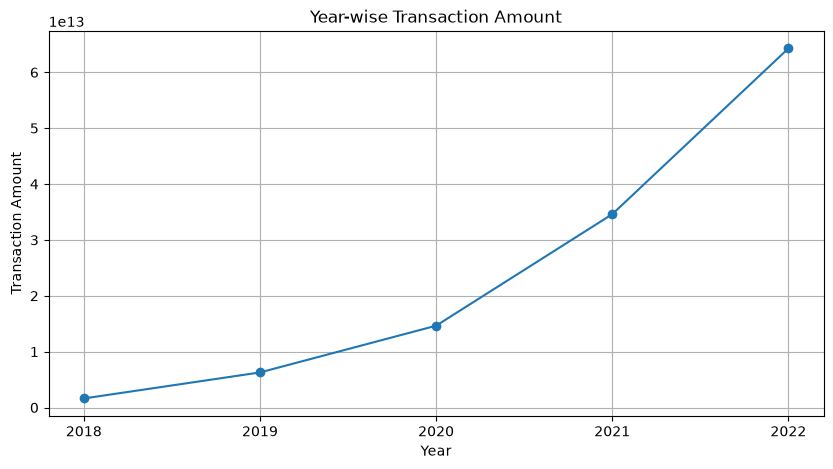

In [10]:
# year wise transaction analysis
yearly_analysis = df.groupby("Year").agg(
    Total_Transactions=("Transaction_count", "sum"),
    Total_Amount=("Transaction_amount", "sum")
).reset_index()

yearly_analysis
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_analysis["Year"],
    yearly_analysis["Total_Amount"],
    marker="o"
)

plt.title("Year-wise Transaction Amount")
plt.xlabel("Year")
plt.ylabel("Transaction Amount")
plt.xticks(yearly_analysis["Year"])
plt.grid(True)

plt.show()


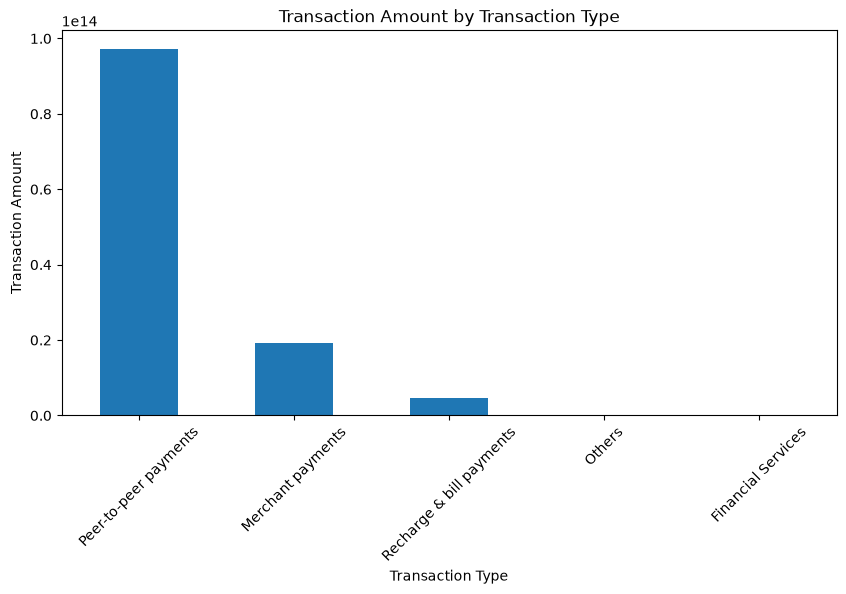

In [11]:
# Transaction type analysis
type_analysis = df.groupby("Transaction_type").agg(
    Total_Transactions=("Transaction_count", "sum"),
    Total_Amount=("Transaction_amount", "sum")
).sort_values(
    "Total_Amount",
    ascending=False
)

type_analysis
plt.figure(figsize=(10, 5))

type_analysis["Total_Amount"].plot(kind="bar")

plt.title("Transaction Amount by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=45)

plt.show()

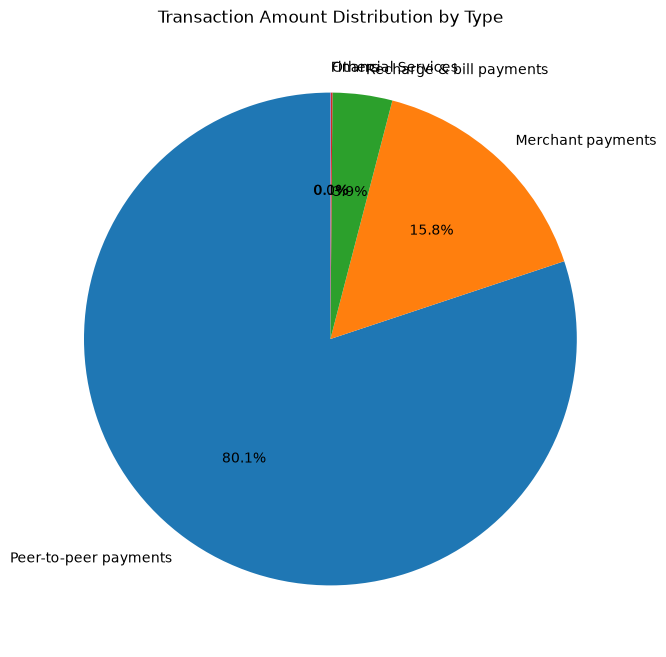

In [25]:
# Transaction type distribution
plt.figure(figsize=(12, 8))

plt.pie(
    type_analysis["Total_Amount"],
    labels=type_analysis.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Transaction Amount Distribution by Type")

plt.show()

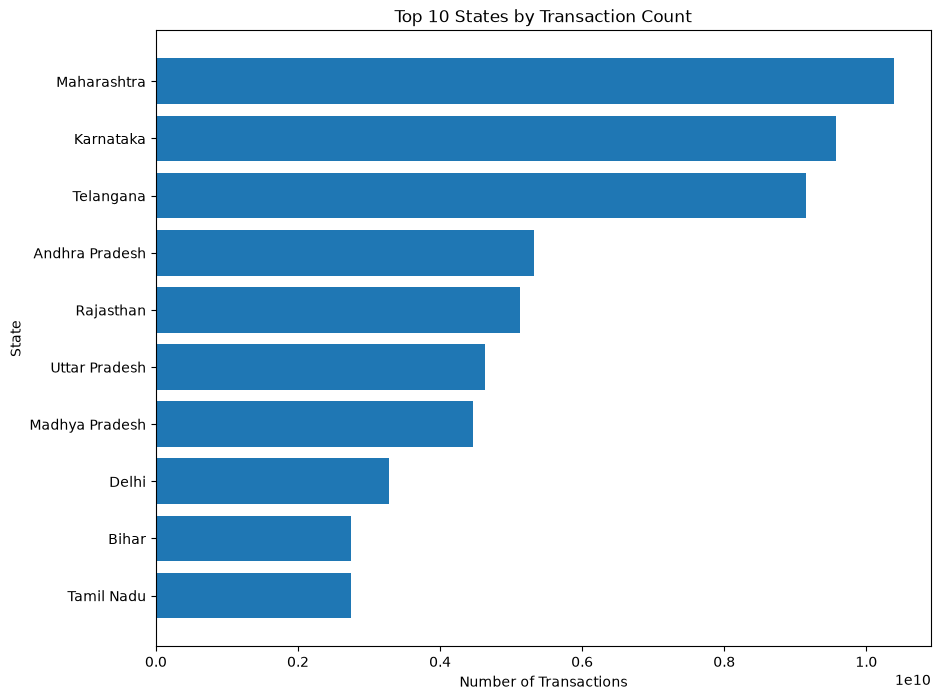

In [31]:
# Top 10 states by transaction count
state_analysis = df.groupby("State").agg(
    Total_Transactions=("Transaction_count", "sum"),
    Total_Amount=("Transaction_amount", "sum")
).sort_values(
    "Total_Amount",
    ascending=False
)

state_analysis.head(10)
top_states_count = state_analysis.sort_values(
    "Total_Transactions",
    ascending=False
).head(10)

plt.figure(figsize=(10, 8))

plt.barh(
    top_states_count.index[::-1],
    top_states_count["Total_Transactions"][::-1]
)

plt.title("Top 10 States by Transaction Count")
plt.xlabel("Number of Transactions")
plt.ylabel("State")

plt.show()

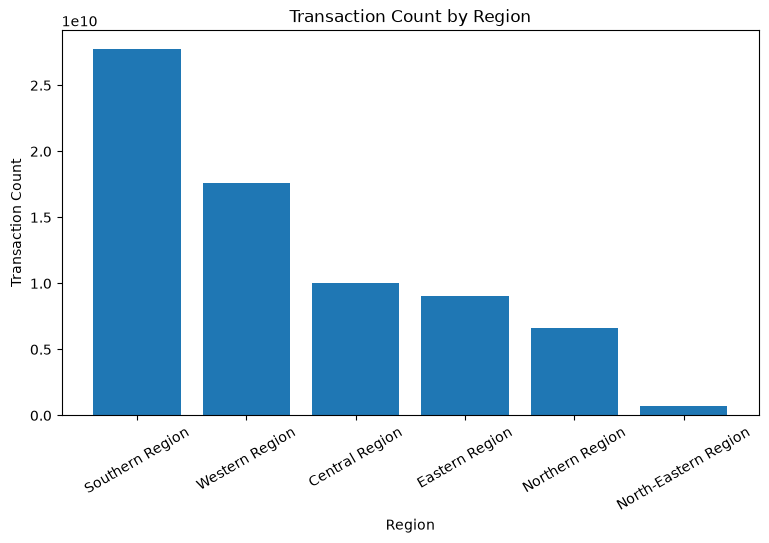

In [26]:
# Region-wise transaction count
region_analysis = df.groupby("Region").agg(
    Total_Transactions=("Transaction_count", "sum"),
    Total_Amount=("Transaction_amount", "sum")
).sort_values(
    "Total_Amount",
    ascending=False
)

region_analysis
plt.figure(figsize=(9, 5))

plt.bar(
    region_analysis.index,
    region_analysis["Total_Transactions"]
)

plt.title("Transaction Count by Region")
plt.xlabel("Region")
plt.ylabel("Transaction Count")
plt.xticks(rotation=30)

plt.show()

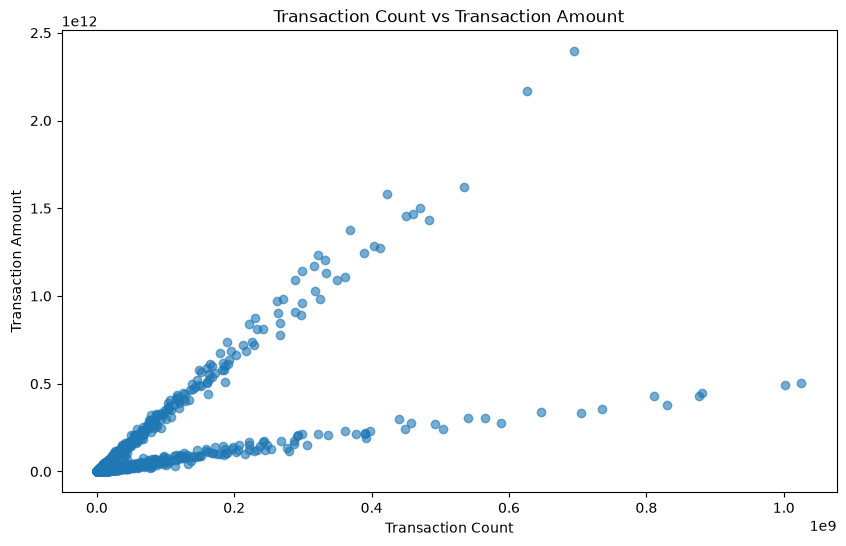

In [27]:
# transaction count vs transaction amount
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Transaction_count"],
    df["Transaction_amount"],
    alpha=0.6
)

plt.title("Transaction Count vs Transaction Amount")
plt.xlabel("Transaction Count")
plt.ylabel("Transaction Amount")

plt.show()

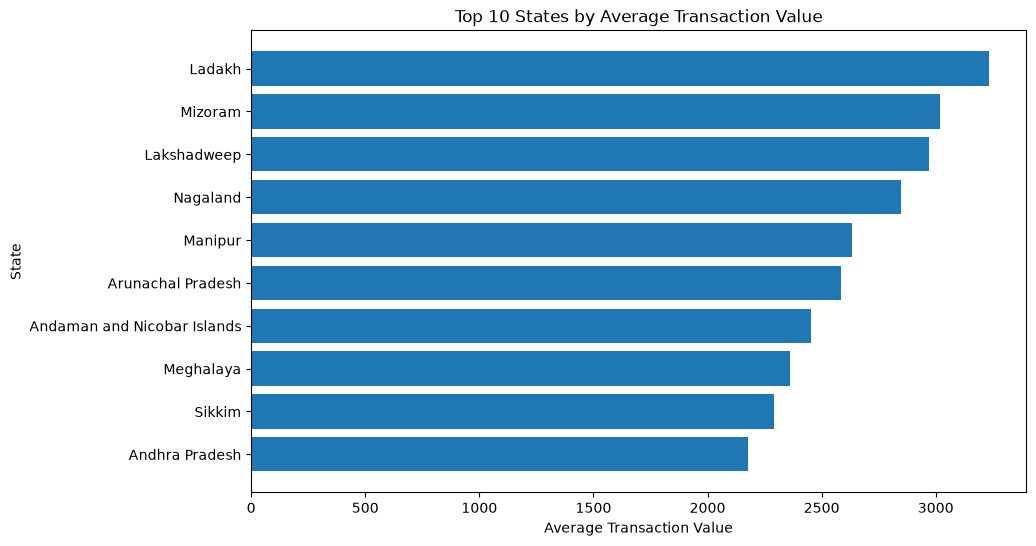

In [30]:
# average transaction value by state
state_analysis["Average_Transaction_Value"] = (
    state_analysis["Total_Amount"] /
    state_analysis["Total_Transactions"]
)

state_analysis.sort_values(
    "Average_Transaction_Value",
    ascending=False
).head(10)
top_avg_states = state_analysis.sort_values(
    "Average_Transaction_Value",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_avg_states.index[::-1],
    top_avg_states["Average_Transaction_Value"][::-1]
)

plt.title("Top 10 States by Average Transaction Value")
plt.xlabel("Average Transaction Value")
plt.ylabel("State")

plt.show()